# 🚔 Análise de Apreensões
 - 📚Bibliotecas utilizadas: Pandas, NumPy, Matplotlib e Seaborn
---

### 🎯 Objetivos deste Desafio


- ✅ Carregar e explorar uma base de ocorrências em Excel.
- ✅ Aplicar **anonimização** de CPF e nome com funções personalizadas.
- ✅ Realizar **tratamento lógico** de dados inválidos (sem apagar linhas).
- ✅ Identificar o **registro representativo único** de cada apreensão (`REP_DADO_UNICO`)
- ✅ Produzir **gráficos e tabelas** (Matplotlib + Seaborn + Pandas)


---

### 📖 Roteiro de Análise

1. **🛠️ Preparação do Ambiente e Carregamento dos Dados**
2. **🔍 Exploração Inicial (EDA rápida)**
3. **🎭 Anonimização de CPF e Nome**
4. **🧹 Tratamento Lógico com `status_dado`**
5. **🧩 Registro Representativo Único (`REP_DADO_UNICO`)**
6. **📈 Análises e Visualizações**
   - ⏳ Distribuição temporal das principais apreensões
   - 🗺️ Distribuição espacial por UF
   - 🛣️ Rodovias mais relevantes
   -  🦹 Pessoas contumazes
7. **🎓 Conclusão e Cheat Sheet**

---
### 💡 Contexto:
- 🧹Combinações de `DS_GRUPO_ENQTO` × `DS_TIPO_APREENSAO` podem gerar **produto cartesiano** (linhas multiplicadas). Por isso, totais de apreensão devem usar apenas linhas com `REP_DADO_UNICO == 'U'`.

## 🛠️ 1. Preparação do Ambiente e Carregamento dos Dados

#### 📦 Bibliotecas utilizadas
- 🧮 **NumPy** — operações numéricas e estatísticas
- 📊 **Pandas** — leitura, limpeza, agrupamentos e tabelas
- 📈 **Matplotlib** — gráficos base (linhas, barras, etc.)
- 🎨 **Seaborn** — gráficos estatísticos mais elegantes

#### 📁 Carregamento do arquivo em Excel no Google Colab
1. Pandas - Leitura automatica


In [23]:
# 📦 Importando as bibliotecas necessárias
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 🎨 Configurações para gráficos mais limpos e legíveis
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='deep')

print('✅ Bibliotecas carregadas com sucesso!')
print(f'\t🧮 NumPy: \t{np.__version__}')
print(f'\t📊 Pandas: \t{pd.__version__}')
print(f'\t🎨 Seaborn: \t{sns.__version__}')


✅ Bibliotecas carregadas com sucesso!
	🧮 NumPy: 	2.1.3
	📊 Pandas: 	2.2.3
	🎨 Seaborn: 	0.13.2


In [24]:
import pandas as pd
CAMINHO_ARQUIVO = 'DADOS_PESSOAS_COMBINADOS.xlsx'

# Leitura
df = pd.read_excel(CAMINHO_ARQUIVO)

print('📂 Arquivo carregado:', CAMINHO_ARQUIVO)
print(f'📏 Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
print('\n📋 Colunas disponíveis:')
for col in df.columns:
    print(f'  • {col}')

📂 Arquivo carregado: DADOS_PESSOAS_COMBINADOS.xlsx
📏 Dimensões: 573746 linhas × 12 colunas

📋 Colunas disponíveis:
  • ID
  • NU_CPF_PESSOA
  • DS_DATA_CURTA
  • DS_TIPO_PESSOA
  • NO_ENVOLVIDO
  • DS_GRUPO_ENQTO
  • DS_COMPLEMENTO
  • DS_RODOVIA
  • DS_UF_LOCAL_OCORRENCIA
  • SG_UF_LOCAL_OCORRENCIA
  • QTDE APREENSâO OCORRÊNCIA
  • DS_TIPO_APREENSAO


# 🔍 2. Exploração Inicial (EDA rápida)

Antes de transformar, **conheça** os dados:
- 👀 `head()` / `tail()` — amostra
- 🧾 `info()` — tipos e nulos
- 📊 `describe()` — estatísticas
- 🔎 `isnull().sum()` — faltantes

> **💡 Lembrete da aula:** limpeza boa começa com diagnóstico bom!


In [25]:
# 🧾 Estrutura, tipos e memória
print('🧾 Informações do DataFrame:\n')
df.info()


🧾 Informações do DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573746 entries, 0 to 573745
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         573746 non-null  int64  
 1   NU_CPF_PESSOA              573746 non-null  object 
 2   DS_DATA_CURTA              573746 non-null  object 
 3   DS_TIPO_PESSOA             494916 non-null  object 
 4   NO_ENVOLVIDO               573746 non-null  object 
 5   DS_GRUPO_ENQTO             573746 non-null  object 
 6   DS_COMPLEMENTO             49906 non-null   object 
 7   DS_RODOVIA                 573746 non-null  object 
 8   DS_UF_LOCAL_OCORRENCIA     573746 non-null  object 
 9   SG_UF_LOCAL_OCORRENCIA     573746 non-null  object 
 10  QTDE APREENSâO OCORRÊNCIA  573746 non-null  float64
 11  DS_TIPO_APREENSAO          573679 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 52.5+ M

In [26]:
# 🔎 Dados ausentes por coluna
print('🧹 Valores ausentes (isnull) por coluna:')
ausentes = df.isnull().sum().sort_values(ascending=False)
display(ausentes[ausentes > 0] if ausentes.sum() > 0 else '✅ Nenhum nulo encontrado com isnull()')

# Estatísticas das colunas numéricas (quando existirem)
print('\n📊 Estatísticas descritivas (numéricas):')
df.describe(include=[np.number])


🧹 Valores ausentes (isnull) por coluna:


,0
DS_COMPLEMENTO,523840
DS_TIPO_PESSOA,78830
DS_TIPO_APREENSAO,67



📊 Estatísticas descritivas (numéricas):


,ID,QTDE APREENSâO OCORRÊNCIA
count,573746.00000,5.737460e+05
mean,286873.50000,2.631825e+03
std,165626.34811,1.027354e+05
min,1.00000,0.000000e+00
25%,143437.25000,1.000000e+00
50%,286873.50000,3.000000e+00
75%,430309.75000,3.600000e+01
max,573746.00000,4.764000e+07


In [27]:
# 🔧 Padronização dos nomes de colunas (espaços extras)
# Mantém os nomes originais o mais próximo possível do enunciado

df.columns = [str(c).strip() for c in df.columns]

# Garante presença das colunas essenciais (falha cedo se faltar alguma)
COLUNAS_ESSENCIAIS = [
    'NU_CPF_PESSOA',
    'DS_DATA_CURTA',
    'NO_ENVOLVIDO',
    'DS_GRUPO_ENQTO',
    'DS_RODOVIA',
    'DS_UF_LOCAL_OCORRENCIA',
    'SG_UF_LOCAL_OCORRENCIA',
    'QTDE APREENSâO OCORRÊNCIA',
    'DS_TIPO_APREENSAO',
]

faltantes = [c for c in COLUNAS_ESSENCIAIS if c not in df.columns]
if faltantes:
    print('⚠️ Atenção: colunas esperadas não encontradas:')
    for c in faltantes:
        print(f'  - {c}')
    print('\n📋 Colunas atuais:', list(df.columns))
    print('\n💡 Se o nome da quantidade vier com grafia diferente (ex.: APREENSÃO),')
    print('   ajuste o dicionário de renomeação abaixo.')
else:
    print('✅ Todas as colunas essenciais foram encontradas!')

# Mapeamento opcional para variações comuns de grafia
renomear = {}
for c in df.columns:
    c_norm = unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode('ascii').upper()
    if 'QTDE' in c_norm and 'APREENS' in c_norm and 'OCORREN' in c_norm:
        renomear[c] = 'QTDE APREENSâO OCORRÊNCIA'
    if c_norm in {'UF_LOCAL_OCORRENCIA', 'DS_UF_LOCAL_OCORRENCIA'}:
        renomear[c] = 'DS_UF_LOCAL_OCORRENCIA'
    if c_norm in {'SG_UF_LOCAL_OCORRENCIA', 'SG_UF'}:
        renomear[c] = 'SG_UF_LOCAL_OCORRENCIA'

if renomear:
    df = df.rename(columns=renomear)
    print('🔁 Colunas padronizadas:', renomear)


✅ Todas as colunas essenciais foram encontradas!
🔁 Colunas padronizadas: {'DS_UF_LOCAL_OCORRENCIA': 'DS_UF_LOCAL_OCORRENCIA', 'SG_UF_LOCAL_OCORRENCIA': 'SG_UF_LOCAL_OCORRENCIA', 'QTDE APREENSâO OCORRÊNCIA': 'QTDE APREENSâO OCORRÊNCIA'}


# 🎭 3. Anonimização de CPF e Nome

## 🎯 Regras:

| Campo | Regra | Exemplo |
|------|------|---------|
| **CPF** (`NU_CPF_PESSOA`) | Manter 3 primeiros dígitos + máscara + último dígito | `123.***.***-*5` |
| **Nome** (`NO_ENVOLVIDO`) | Iniciais em caixa alta (ignorando partículas) | `Joao Jose da Silva Nogueira` → `JJSN` |

Os resultados vão para **novas colunas** (os originais permanecem na base bruta para auditoria interna — mas nos gráficos usaremos só as versões anonimizadas quando fizer sentido).

> **🔐 Boas práticas:** em relatórios públicos, prefira sempre exibir `CPF_ANON` e `NOME_INICIAIS`.


In [28]:
# 🎭 Funções de anonimização

PARTICULAS_NOME = {
    'DA', 'DE', 'DO', 'DAS', 'DOS', 'E', 'A', 'O', 'AS', 'OS',
    'DI', 'DU', 'DEL', 'DELLA', 'VAN', 'VON'
}


def apenas_digitos(valor):
    """Extrai somente dígitos de um valor (CPF)."""
    if pd.isna(valor):
        return ''
    return re.sub(r'\D', '', str(valor))


def anonimizar_cpf(cpf) -> object:
    """Anonimiza CPF no formato 123.***.***-*5.

    - Usa os 3 primeiros dígitos
    - Mascara o meio com ***.***-*
    - Mantém apenas o último dígito
    """
    digitos = apenas_digitos(cpf)
    if len(digitos) < 4:
        return None
    return f"{digitos[:3]}.***.***-*{digitos[-1]}"


def iniciais_nome(nome) -> object:
    """Gera iniciais em caixa alta, ignorando partículas (da, de, do...).

    Ex.: 'Joao Jose da Silva Nogueira' -> 'JJSN'
    """
    if pd.isna(nome):
        return None
    texto = str(nome).strip()
    if not texto:
        return None

    # Remove acentos
    tokens = re.findall(r"[A-Za-zÀ-ÿ]+", texto)
    iniciais = []
    for token in tokens:
        token_up = unicodedata.normalize('NFKD', token).encode('ascii', 'ignore').decode('ascii').upper()
        if token_up in PARTICULAS_NOME:
            continue
        if token_up:
            iniciais.append(token_up[0])
    return ''.join(iniciais) if iniciais else None


# ✅ Testes rápidos - validação de função
print('🧪 Testes de anonimização:')
print(' CPF 123.456.789-05 ->', anonimizar_cpf('123.456.789-05'))
print(' CPF 12345678905    ->', anonimizar_cpf('12345678905'))
print(' Nome exemplo       ->', iniciais_nome('Joao Jose da Silva Nogueira'))
print(' Nome com acento    ->', iniciais_nome('José Antônio de Oliveira'))


🧪 Testes de anonimização:
 CPF 123.456.789-05 -> 123.***.***-*5
 CPF 12345678905    -> 123.***.***-*5
 Nome exemplo       -> JJSN
 Nome com acento    -> JAO


In [29]:
import pandas as pd
from IPython.display import display

# 🆕 Criando colunas anonimizadas
df['CPF_ANON'] = df['NU_CPF_PESSOA'].apply(anonimizar_cpf)
df['NOME_INICIAIS'] = df['NO_ENVOLVIDO'].apply(iniciais_nome)

print('✅ Colunas criadas: CPF_ANON e NOME_INICIAIS - Dados reais apresenados abaixo:')
display(df[['CPF_ANON', 'NOME_INICIAIS']])

✅ Colunas criadas: CPF_ANON e NOME_INICIAIS - Dados reais apresenados abaixo:


,CPF_ANON,NOME_INICIAIS
0,041.***.***-*2,JRLJ
1,041.***.***-*2,JRLJ
2,041.***.***-*2,JRLJ
3,048.***.***-*5,LHLA
4,759.***.***-*3,NAP
...,...,...
573741,779.***.***-*0,ZMMN
573742,779.***.***-*0,ZMMN
573743,288.***.***-*0,ZRM
573744,288.***.***-*0,ZRM


# 🧹 4. Tratamento Lógico com `status_dado`

## 🎯 Ideia-chave
**Não apagar linhas**: criamos uma coluna de status que decide se o registro entra nos relatórios/gráficos.

### ❌ CPF considerado inválido para apresentação quando:
- estiver em branco (`''`)
- for nulo (`NaN` / `None`)
- contiver textos como **"nao informado"** / **"não informado"** / **"ni"** etc.

| `status_dado` | Significado |
|---|---|
| `APRESENTAR` | Linha apta para relatórios e gráficos |
| `NAO_APRESENTAR` | Linha mantida na base, mas fora das análises |

> **💡 Técnica da aula:** criar colunas derivadas com `.apply()` / condições vetorizadas é um clássico de limpeza com Pandas!


In [30]:
# 🧹 Função de classificação lógica do CPF

INVALIDOS_TEXTO = {
    'nao informado', 'não informado', 'nao_informado', 'não_informado',
    'naoinformado', 'nãoinformado', 'ni', 'n/i', 'n.i.', 'n.i',
    'sem informacao', 'sem informação', 'null', 'none', 'nan', '-', '--', 'n/a'
}


def classificar_status_cpf(cpf):
    """Retorna APRESENTAR ou NAO_APRESENTAR com base no CPF."""
    if pd.isna(cpf):
        return 'NAO_APRESENTAR'

    texto = str(cpf).strip()
    if texto == '':
        return 'NAO_APRESENTAR'

    texto_norm = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    texto_norm = texto_norm.strip().lower()
    if texto_norm in INVALIDOS_TEXTO:
        return 'NAO_APRESENTAR'

    digitos = apenas_digitos(texto)
    # CPF brasileiro tem 11 dígitos; se não houver dígitos suficientes, não apresenta
    if len(digitos) < 11:
        return 'NAO_APRESENTAR'

    return 'APRESENTAR'


df['status_dado'] = df['NU_CPF_PESSOA'].apply(classificar_status_cpf)

resumo_status = df['status_dado'].value_counts(dropna=False)
print('📊 Distribuição de status_dado:')
print(resumo_status)
print()
print(f"✅ Aptos (APRESENTAR): {(df['status_dado'] == 'APRESENTAR').sum()}")
print(f"🚫 Excluídos logicamente (NAO_APRESENTAR): {(df['status_dado'] == 'NAO_APRESENTAR').sum()}")

display(df[['CPF_ANON', 'status_dado']])


📊 Distribuição de status_dado:
status_dado
APRESENTAR        573009
NAO_APRESENTAR       737
Name: count, dtype: int64

✅ Aptos (APRESENTAR): 573009
🚫 Excluídos logicamente (NAO_APRESENTAR): 737


,CPF_ANON,status_dado
0,041.***.***-*2,APRESENTAR
1,041.***.***-*2,APRESENTAR
2,041.***.***-*2,APRESENTAR
3,048.***.***-*5,APRESENTAR
4,759.***.***-*3,APRESENTAR
...,...,...
573741,779.***.***-*0,APRESENTAR
573742,779.***.***-*0,APRESENTAR
573743,288.***.***-*0,APRESENTAR
573744,288.***.***-*0,APRESENTAR


/tmp/ipykernel_61663/621267546.py:17: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


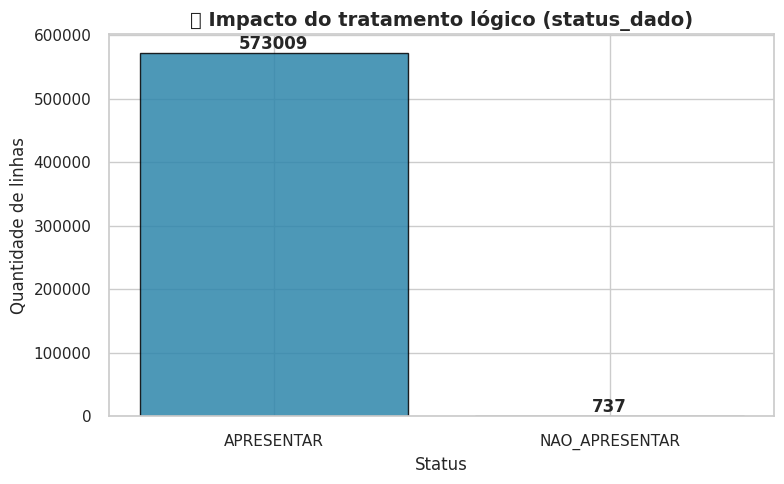

In [31]:
# 📊 Visualização didática do impacto do tratamento lógico
fig, ax = plt.subplots(figsize=(8, 5))
cores = {'APRESENTAR': '#2E86AB', 'NAO_APRESENTAR': '#E76F51'}
ordem = ['APRESENTAR', 'NAO_APRESENTAR']
contagem = df['status_dado'].value_counts().reindex(ordem).fillna(0)

bars = ax.bar(ordem, contagem.values, color=[cores[o] for o in ordem], edgecolor='black', alpha=0.85)
ax.set_title('🧹 Impacto do tratamento lógico (status_dado)', fontsize=14, fontweight='bold')
ax.set_ylabel('Quantidade de linhas')
ax.set_xlabel('Status')

for b in bars:
    ax.annotate(f'{int(b.get_height())}',
                xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# 🧩 5. Registro Representativo Único (`REP_DADO_UNICO`)

## 🧠 Por que isso é necessário?
Quando uma ocorrência combina **múltiplos grupos de enquadramento** `DS_GRUPO_ENQTO` com **múltiplos tipos de apreensão** `DS_TIPO_APREENSAO`, a base pode sofrer **produto cartesiano** (linhas se multiplicam).

Isso ocorre devido a possibilidade de uma determinada ocorrência ser enquadrada em mais de um grupo, como por exemplo: Crimes contra a fé pública e Drogas ilícitas se a pessoa usava documento falso e transportava drogas...

Se somarmos a quantidade apreendida em todas as linhas, **inflamos o total**.

### ✅ Estratégia (sem apagar linhas)
1. Agrupar pela ocorrência/apreensão:
   - `NU_CPF_PESSOA`
   - `DS_DATA_CURTA`
   - `DS_TIPO_APREENSAO`
   - `QTDE APREENSâO OCORRÊNCIA`
2. Marcar **apenas a primeira linha** de cada grupo com `"U"`
3. Demais linhas do mesmo grupo ficam `None` (vazio)
4. Totais oficiais: filtrar `REP_DADO_UNICO == 'U'`

> **🎯 Resultado:** estrutura da tabela preservada + totais confiáveis.


In [32]:
# 🧩 Função para marcar o registro representativo único

COL_QTDE = 'QTDE APREENSâO OCORRÊNCIA'

CHAVES_GRUPO = [
    'NU_CPF_PESSOA',
    'DS_DATA_CURTA',
    'DS_TIPO_APREENSAO',
    COL_QTDE,
]


def marcar_rep_dado_unico(dataframe, chaves=None):
    """Cria/atualiza a coluna REP_DADO_UNICO.

    Para cada grupo (ocorrência + características da apreensão),
    marca 'U' apenas na primeira linha; demais recebem None.
    """
    chaves = chaves or CHAVES_GRUPO
    out = dataframe.copy()

    # Garante que as chaves existam
    faltando = [c for c in chaves if c not in out.columns]
    if faltando:
        raise KeyError(f'Colunas de agrupamento ausentes: {faltando}')

    # Inicializa vazio
    out['REP_DADO_UNICO'] = None

    # groupby().cumcount() == 0 identifica a primeira linha de cada grupo
    primeira = out.groupby(chaves, dropna=False).cumcount() == 0
    out.loc[primeira, 'REP_DADO_UNICO'] = 'U'

    return out


df = marcar_rep_dado_unico(df)

n_u = (df['REP_DADO_UNICO'] == 'U').sum()
n_dup = df['REP_DADO_UNICO'].isna().sum()
print('✅ Coluna REP_DADO_UNICO criada!')
print(f'🏷️  Registros únicos (U): {n_u}')
print(f'📄 Linhas complementares (vazias): {n_dup}')
print(f'📐 Total de linhas: {len(df)}\n\n')

df[CHAVES_GRUPO + ['DS_GRUPO_ENQTO', 'REP_DADO_UNICO']].info(15)


✅ Coluna REP_DADO_UNICO criada!
🏷️  Registros únicos (U): 421892
📄 Linhas complementares (vazias): 151854
📐 Total de linhas: 573746


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573746 entries, 0 to 573745
Data columns (total 6 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NU_CPF_PESSOA              573746 non-null  object 
 1   DS_DATA_CURTA              573746 non-null  object 
 2   DS_TIPO_APREENSAO          573679 non-null  object 
 3   QTDE APREENSâO OCORRÊNCIA  573746 non-null  float64
 4   DS_GRUPO_ENQTO             573746 non-null  object 
 5   REP_DADO_UNICO             421892 non-null  object 
dtypes: float64(1), object(5)
memory usage: 26.3+ MB


In [33]:
def marcar_cont_prisao(dataframe):
    """Marca 'P' para cada prisão única baseada em CPF e Data Curta.

    Para cada grupo (CPF + Data Curta), marca 'P' apenas na primeira linha;
    demais linhas do mesmo grupo recebem None.
    """
    out = dataframe.copy()
    chaves_prisao = ['NU_CPF_PESSOA', 'DS_DATA_CURTA']

    faltando = [c for c in chaves_prisao if c not in out.columns]
    if faltando:
        raise KeyError(f'Colunas de agrupamento ausentes para prisão: {faltando}')

    out['CONT_PRISAO'] = None
    primeira_prisao = out.groupby(chaves_prisao, dropna=False).cumcount() == 0
    out.loc[primeira_prisao, 'CONT_PRISAO'] = 'P'

    return out

df = marcar_cont_prisao(df)

n_p = (df['CONT_PRISAO'] == 'P').sum()
n_na = df['CONT_PRISAO'].isna().sum()

print('✅ Coluna CONT_PRISAO criada!')
print(f'🏷️  Registros de prisão únicos (P): {n_p}')
print(f'📄 Linhas complementares (vazias): {n_na}')
print(f'📐 Total de linhas: {len(df)}\n\n')

# Exibindo um resumo para a nova coluna e as chaves de agrupamento
display(df[['NU_CPF_PESSOA', 'DS_DATA_CURTA', 'DS_TIPO_APREENSAO', 'REP_DADO_UNICO', 'CONT_PRISAO']].head(20))

✅ Coluna CONT_PRISAO criada!
🏷️  Registros de prisão únicos (P): 238142
📄 Linhas complementares (vazias): 335604
📐 Total de linhas: 573746




,NU_CPF_PESSOA,DS_DATA_CURTA,DS_TIPO_APREENSAO,REP_DADO_UNICO,CONT_PRISAO
0,041.495.073-92,24/11/2016,CRLV / CRV,U,P
1,041.495.073-92,24/11/2016,CRLV / CRV,None,None
2,041.495.073-92,24/11/2016,CRLV / CRV,None,None
3,048.218.043-95,20/04/2015,Silvestres,U,P
4,759.649.963-53,25/06/2024,AUTOMÓVEL,U,P
5,759.649.963-53,25/06/2024,AUTOMÓVEL,None,None
6,131.531.124-01,19/08/2022,Anfetaminas,U,P
7,027.845.494-10,24/04/2020,Guia Florestal,U,P
8,027.845.494-10,24/04/2020,Nativas,U,None
9,027.845.494-10,24/04/2020,Guia Florestal,None,None


A nova coluna `CONT_PRISAO` foi criada para identificar cada **prisão única** (baseada no `NU_CPF_PESSOA` e `DS_DATA_CURTA`).

- O valor `'P'` indica a primeira ocorrência de uma prisão para aquele CPF e data.
- Valores `None` indicam que a linha é uma ocorrência subsequente da mesma prisão (mesmo CPF, mesma data), mas com diferentes detalhes de apreensão.

**Como usar:**

Para contar o número total de prisões únicas, você deve filtrar `df['CONT_PRISAO'] == 'P'`. Esta coluna é essencial para análises que buscam a frequência de prisões de indivíduos, e não a quantidade total de itens apreendidos.

```python
# Exemplo de uso para contar prisões únicas
total_prisoes_unicas = df[df['CONT_PRISAO'] == 'P'].shape[0]
print(f"Total de prisões únicas identificadas: {total_prisoes_unicas}")

# Exemplo de um DataFrame analítico para prisões
df_analise_prisoes = df[(df['status_dado'] == 'APRESENTAR') & (df['CONT_PRISAO'] == 'P')].copy()
```

In [34]:
# 🔬 Demonstração: por que filtrar REP_DADO_UNICO == 'U' importa

# Base analítica oficial
mask_valida = (df['status_dado'] == 'APRESENTAR') & (df['REP_DADO_UNICO'] == 'U')
df_analise = df.loc[mask_valida].copy()

# Garante quantidade numérica
df_analise[COL_QTDE] = pd.to_numeric(df_analise[COL_QTDE], errors='coerce').fillna(0)

soma_com_cartesiano = pd.to_numeric(df.loc[df['status_dado'] == 'APRESENTAR', COL_QTDE], errors='coerce').fillna(0).sum()
soma_unica = df_analise[COL_QTDE].sum()

print('🧮 Comparativo de totais (apenas status APRESENTAR):')
print(f'  • Soma SEM filtro REP_DADO_UNICO: {soma_com_cartesiano:,.0f}')
print(f'  • Soma COM filtro REP_DADO_UNICO == "U": {soma_unica:,.0f}')
print(f'  • Diferença (possível inflação): {soma_com_cartesiano - soma_unica:,.0f}')
print()
print(f'📏 Linhas na base analítica (APRESENTAR ∩ U): {len(df_analise)}')


🧮 Comparativo de totais (apenas status APRESENTAR):
  • Soma SEM filtro REP_DADO_UNICO: 1,502,762,187
  • Soma COM filtro REP_DADO_UNICO == "U": 1,123,710,638
  • Diferença (possível inflação): 379,051,549

📏 Linhas na base analítica (APRESENTAR ∩ U): 421498


# 📈 6. Análises e Visualizações

A partir daqui usamos **`df_analise`**:
- ✅ `status_dado == 'APRESENTAR'`
- ✅ `REP_DADO_UNICO == 'U'`

### 🎯 Perguntas de negócio
1. **⏳ Temporal:** como as principais apreensões se distribuem no tempo?
2. **🗺️ Espacial:** quais UFs concentram as principais apreensões?
3. **🛣️ Rodovias:** qual rodovia é mais relevante em volume apreendido?


In [35]:
# 📅 Preparação da dimensão temporal
# DS_DATA_CURTA pode vir como texto/data — forçamos datetime

df_analise['DATA'] = pd.to_datetime(df_analise['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
df_analise['ANO_MES'] = df_analise['DATA'].dt.to_period('M').astype(str)
df_analise['ANO'] = df_analise['DATA'].dt.year
df_analise['MES'] = df_analise['DATA'].dt.month

print('📅 Cobertura temporal:')
print(f"  Mínimo: {df_analise['DATA'].min()}")
print(f"  Máximo: {df_analise['DATA'].max()}")
print(f"  Nulos de data: {df_analise['DATA'].isna().sum()}")

# UF de trabalho: prefere sigla; se vazia, usa descrição
df_analise['UF'] = df_analise['SG_UF_LOCAL_OCORRENCIA'].fillna(df_analise['DS_UF_LOCAL_OCORRENCIA'])
df_analise['UF'] = df_analise['UF'].astype(str).str.strip().str.upper().replace({'NAN': np.nan, 'NONE': np.nan})

print('\n🗺️ UFs encontradas (amostra):', df_analise['UF'].dropna().unique()[:15])


📅 Cobertura temporal:
  Mínimo: 2014-01-22 00:00:00
  Máximo: 2026-08-24 00:00:00
  Nulos de data: 0

🗺️ UFs encontradas (amostra): ['CE' 'AM' 'AL' 'BA' 'MA' 'AP' 'PI' 'DF' 'GO' 'AC' 'ES' 'RN' 'RO' 'RR'
 'PE']


## ⏳ 6.1 Distribuição temporal das principais apreensões

> **Técnica:** identificar o Top N de `DS_TIPO_APREENSAO` por quantidade e plotar série temporal (`plt.plot` / Seaborn `lineplot`).


In [36]:
# 🏆 Top tipos de apreensão por quantidade total
TOP_N = 10  # 👈 ajuste se quiser mais/menos categorias

ranking_tipos = (
    df_analise.groupby('DS_TIPO_APREENSAO', dropna=False)[COL_QTDE]
    .sum()
    .sort_values(ascending=False)
)

print('🏆 Ranking geral — quantidade apreendida por tipo:')
display(ranking_tipos.head(10).to_frame('QTDE_TOTAL'))

principais_tipos = ranking_tipos.head(TOP_N).index.tolist()
print('\n📌 Principais apreensões selecionadas para a série temporal:')
for i, t in enumerate(principais_tipos, 1):
    print(f'  {i}. {t}')


🏆 Ranking geral — quantidade apreendida por tipo:


,QTDE_TOTAL
DS_TIPO_APREENSAO,
Cigarros,3.566788e+08
Real,3.194127e+08
Milho em graos,4.775511e+07
DEXTROSE 96DE GRANEL,4.686000e+07
Outro tipo,4.265521e+07
Outra Moeda,3.664247e+07
Sementes e grãos,3.413299e+07
Dólar,2.603580e+07
Cigarro,2.011770e+07



📌 Principais apreensões selecionadas para a série temporal:
  1. Cigarros
  2. Real
  3. Milho em graos
  4. DEXTROSE 96DE GRANEL
  5. Outro tipo
  6. Outra Moeda
  7. Sementes e grãos
  8. Dólar
  9. Cigarro
  10. Cerveja


/tmp/ipykernel_61663/3867445537.py:42: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


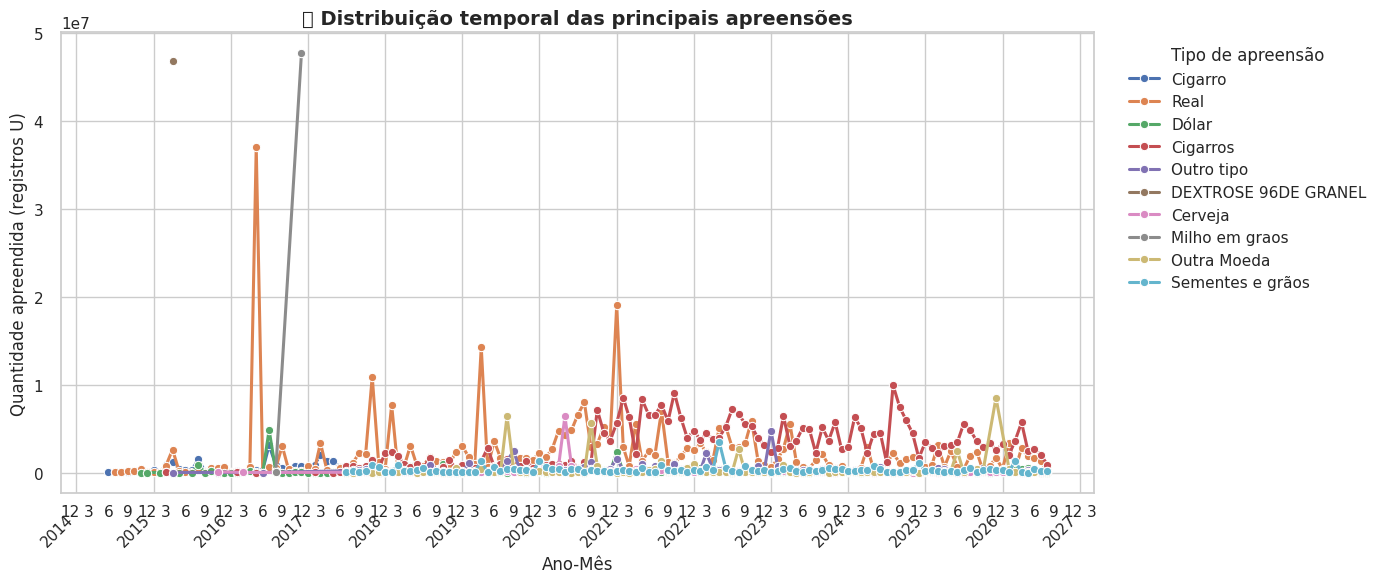

📋 Tabela (Ano-Mês × Tipo) — principais apreensões:


In [37]:
# 📈 Série temporal (mês) das principais apreensões
import matplotlib.dates as mdates

filtro_tempo = df_analise['DS_TIPO_APREENSAO'].isin(principais_tipos) & df_analise['ANO_MES'].notna()
temporal = (
    df_analise.loc[filtro_tempo]
    .groupby(['ANO_MES', 'DS_TIPO_APREENSAO'], as_index=False)[COL_QTDE]
    .sum()
    .sort_values('ANO_MES')
)

plt.figure(figsize=(14, 6))
ax = sns.lineplot(
    data=temporal,
    x=pd.to_datetime(temporal['ANO_MES']), # Convert to datetime for proper time series plotting
    y=COL_QTDE,
    hue='DS_TIPO_APREENSAO',
    marker='o',
    linewidth=2.2
)

# Set major locator and formatter for years
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format as year

# Set minor locator and formatter for months (e.g., every 3 months)
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Custom formatter to remove leading zero from month number for minor ticks
def custom_month_formatter(x, pos):
    dt = mdates.num2date(x)
    return f"{dt.month}"
ax.xaxis.set_minor_formatter(plt.FuncFormatter(custom_month_formatter))

# Rotate labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('⏳ Distribuição temporal das principais apreensões', fontsize=14, fontweight='bold')
plt.xlabel('Ano-Mês')
plt.ylabel('Quantidade apreendida (registros U)')
plt.legend(title='Tipo de apreensão', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 📋 Tabela complementar (pivot)
pivot_temporal = temporal.pivot_table(
    index='ANO_MES',
    columns='DS_TIPO_APREENSAO',
    values=COL_QTDE,
    aggfunc='sum',
    fill_value=0
)
print('📋 Tabela (Ano-Mês × Tipo) — principais apreensões:')
#display(pivot_temporal)


## 🗺️ 6.2 Distribuição espacial por UF das apreensões de drogas

> **Técnica:** `groupby` + `pivot_table` + `sns.heatmap` / barras empilhadas para ler concentração geográfica.


In [ ]:
# 🗺️ Concentração por UF × tipo (apreensões de drogas - lei dos tóxicos)

# Base de dados: APRESENTAR + registro representativo único (evita inflação por produto cartesiano)
base_df_temp = df.loc[(df['status_dado'] == 'APRESENTAR') & (df['REP_DADO_UNICO'] == 'U')].copy()

# Derivar a coluna 'UF' para esta base temporária, similar a como foi feito para df_analise
base_df_temp['UF'] = base_df_temp['SG_UF_LOCAL_OCORRENCIA'].fillna(base_df_temp['DS_UF_LOCAL_OCORRENCIA'])
base_df_temp['UF'] = base_df_temp['UF'].astype(str).str.strip().str.upper().replace({'NAN': np.nan, 'NONE': np.nan})


# Exibir os valores únicos de DS_GRUPO_ENQTO para depuração
# Caso o filtro abaixo não retorne dados, é provável que o valor 'lei dos tóxicos' esteja escrito de forma diferente
print('Valores únicos e padronizados em DS_GRUPO_ENQTO:')
normalized_groups = base_df_temp['DS_GRUPO_ENQTO'].str.strip().str.lower().unique()
display(pd.Series(normalized_groups).sort_values().to_frame('DS_GRUPO_ENQTO_NORMALIZADO'))

# Aplicar o filtro para 'lei dos tóxicos'
filtro_geo_drogas = (base_df_temp['DS_GRUPO_ENQTO'].str.strip().str.lower() == 'lei dos tóxicos') & base_df_temp['UF'].notna()

base_df_temp[COL_QTDE] = pd.to_numeric(base_df_temp[COL_QTDE], errors='coerce').fillna(0)

geo_drogas = (
    base_df_temp.loc[filtro_geo_drogas]
    .groupby(['UF', 'DS_TIPO_APREENSAO'], as_index=False)[COL_QTDE]
    .sum()
)

pivot_geo_drogas = geo_drogas.pivot_table(
    index='UF',
    columns='DS_TIPO_APREENSAO',
    values=COL_QTDE,
    aggfunc='sum',
    fill_value=0
)

# Verifica se o DataFrame pivotado está vazio antes de tentar plotar
if pivot_geo_drogas.empty:
    print("\n⚠️ Não há dados de apreensão para 'lei dos tóxicos' após o filtro. Verifique os valores únicos acima.")
else:
    # Calcula o total por UF para ranking
    pivot_geo_drogas['__TOTAL__'] = pivot_geo_drogas.sum(axis=1)
    pivot_geo_drogas = pivot_geo_drogas.sort_values('__TOTAL__', ascending=False)
    totais_uf_drogas = pivot_geo_drogas['__TOTAL__'].copy()
    pivot_geo_drogas = pivot_geo_drogas.drop(columns='__TOTAL__')

    print('🗺️ Ranking de UFs (soma das apreensões de drogas - lei dos tóxicos):')
    display(totais_uf_drogas.head(10).to_frame('QTDE_TOTAL'))

    # Identifica os TOP N tipos de apreensão no grupo 'lei dos tóxicos'
    TOP_N_TIPOS_APREENSAO = 7 # Ajuste este valor conforme necessidade
    top_tipos_drogas = geo_drogas.groupby('DS_TIPO_APREENSAO')[COL_QTDE].sum().nlargest(TOP_N_TIPOS_APREENSAO).index.tolist()

    # Filtra o pivot table para incluir apenas os TOP N tipos e as TOP 10 UFs
    df_plot = pivot_geo_drogas.loc[totais_uf_drogas.head(10).index, top_tipos_drogas]

    # Cria o stacked bar chart
    plt.figure(figsize=(14, 8))
    df_plot.plot(kind='barh', stacked=True, cmap='viridis', ax=plt.gca())
    plt.title('🗺️ Top 10 UFs — Composição das Apreensões (Lei dos Tóxicos)', fontsize=14, fontweight='bold')
    plt.xlabel('Quantidade apreendida')
    plt.ylabel('UF')
    plt.legend(title='Tipo de apreensão', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# 📊 Barras: Top UFs no total apreendido (Lei dos Tóxicos)
# Usa totais_uf_drogas criado na célula anterior do item 6.2

if 'totais_uf_drogas' not in globals() or len(totais_uf_drogas) == 0:
    print('⚠️ Sem dados em totais_uf_drogas. Execute a célula anterior do 6.2 e verifique o filtro "lei dos tóxicos".')
else:
    top_ufs = totais_uf_drogas.head(10)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x=top_ufs.values, y=top_ufs.index, orient='h', color='#2E86AB', ax=ax)
    ax.set_title('🏅 Top 10 UFs — volume das apreensões (Lei dos Tóxicos)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Quantidade apreendida (registros U)')
    ax.set_ylabel('UF')

    for i, v in enumerate(top_ufs.values):
        ax.text(v, i, f' {v:,.0f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()


## 🛣️ 6.3 Qual rodovia é mais relevante?

> **Critério:** maior soma de `QTDE APREENSâO OCORRÊNCIA` nos registros únicos válidos (`REP_DADO_UNICO == 'U'`).

Complementamos com composição por tipo de apreensão nas rodovias líderes.


In [ ]:
# 🛣️ Ranking de rodovias por quantidade apreendida
rodovias = (
    df_analise.groupby('DS_RODOVIA', dropna=False)[COL_QTDE]
    .agg(qtde_total='sum', n_registros='count')
    .sort_values('qtde_total', ascending=False)
)

# Remove rótulos vazios óbvios
rodovias = rodovias[~rodovias.index.astype(str).str.strip().str.lower().isin(['', 'nan', 'none', 'nao informado', 'não informado'])]

print('🛣️ Ranking de rodovias (top 15):')
display(rodovias.head(15))

if len(rodovias) == 0:
    print('⚠️ Nenhuma rodovia válida encontrada para ranquear.')
else:
    campeã = rodovias.index[0]
    print(f"\n🏆 Rodovia mais relevante: {campeã}")
    print(f"   Quantidade total apreendida: {rodovias.iloc[0]['qtde_total']:,.0f}")
    print(f"   Nº de registros únicos (U): {int(rodovias.iloc[0]['n_registros'])}")


In [ ]:
# 📊 Visualização — Top rodovias
TOP_RODOVIAS = 10
top_rod = rodovias.head(TOP_RODOVIAS).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontais
sns.barplot(
    data=top_rod,
    x='qtde_total',
    y='DS_RODOVIA',
    color='#52B788',
    ax=axes[0]
)
axes[0].set_title(f'🛣️ Top {TOP_RODOVIAS} rodovias por quantidade apreendida', fontweight='bold')
axes[0].set_xlabel('Quantidade apreendida')
axes[0].set_ylabel('Rodovia')

# Composição por tipo na rodovia campeã (se houver)
if len(rodovias) > 0:
    campeã = rodovias.index[0]
    comp = (
        df_analise.loc[df_analise['DS_RODOVIA'] == campeã]
        .groupby('DS_TIPO_APREENSAO')[COL_QTDE]
        .sum()
        .sort_values(ascending=False)
        .head(8)
    )
    axes[1].pie(
        comp.values,
        labels=comp.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    axes[1].set_title(f'🧩 Composição por tipo — {campeã}', fontweight='bold')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()


## 🔎 6.4 Extras didáticos (funções da aula)

Aqui reforçamos técnicas vistas em 1.1 e 1.2:
- 📊 `groupby().agg()` com múltiplas métricas
- 🧮 estatísticas com **NumPy**
- 📦 `boxplot` / `hist` para distribuição das quantidades


In [ ]:
# 📊 Agregações múltiplas por tipo de apreensão
agg_tipos = (
    df_analise.groupby('DS_TIPO_APREENSAO')[COL_QTDE]
    .agg(total='sum', media='mean', mediana='median', registros='count', desvio='std')
    .sort_values('total', ascending=False)
)

print('📋 Agregações por DS_TIPO_APREENSAO:')
display(agg_tipos.head(10))

# 🧮 Estatísticas com NumPy sobre as quantidades
qtdes = df_analise[COL_QTDE].to_numpy(dtype=float)
print('\n🧮 Estatísticas NumPy (quantidades nos registros U):')
print(f'  Média: {np.mean(qtdes):.2f}')
print(f'  Mediana: {np.median(qtdes):.2f}')
print(f'  Desvio padrão: {np.std(qtdes):.2f}')
print(f'  Mínimo: {np.min(qtdes):.2f}')
print(f'  Máximo: {np.max(qtdes):.2f}')
print(f'  25º percentil: {np.percentile(qtdes, 25):.2f}')
print(f'  75º percentil: {np.percentile(qtdes, 75):.2f}')


In [ ]:
# 📦 Distribuição das quantidades (hist + boxplot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
ax1.hist(df_analise[COL_QTDE], bins=20, color='#52B788', alpha=0.8, edgecolor='black')
ax1.set_title('📊 Histograma — QTDE apreendida (registros U)', fontweight='bold')
ax1.set_xlabel('Quantidade')
ax1.set_ylabel('Frequência')

# Boxplot dos principais tipos
dados_box = df_analise[df_analise['DS_TIPO_APREENSAO'].isin(principais_tipos)]
sns.boxplot(data=dados_box, x='DS_TIPO_APREENSAO', y=COL_QTDE, ax=ax2, color='#2E86AB')
ax2.set_title('📦 Boxplot — principais tipos', fontweight='bold')
ax2.set_xlabel('Tipo de apreensão')
ax2.set_ylabel('Quantidade')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [ ]:
# 🧾 Amostra final “pronta para relatório” (dados anonimizados)
colunas_relatorio = [
    'CPF_ANON', 'NOME_INICIAIS', 'DS_DATA_CURTA', 'UF', 'DS_RODOVIA',
    'DS_TIPO_APREENSAO', COL_QTDE, 'status_dado', 'REP_DADO_UNICO'
]
colunas_relatorio = [c for c in colunas_relatorio if c in df_analise.columns]

print('🔐 Amostra para relatório (sem CPF/nome em claro):')
display(df_analise[colunas_relatorio].head(15))

# 💾 Exportação opcional
# df_analise[colunas_relatorio].to_excel('apreensoes_analise_anonimizada.xlsx', index=False)
# print('✅ Arquivo exportado: apreensoes_analise_anonimizada.xlsx')


## 🦹 6.4 Principais Contumazes

> **Critério:** Indivíduos (`CPF_ANON`) com múltiplas ocorrências de apreensão (`REP_DADO_UNICO == 'U'`) em um mesmo ano (`ANO`), indicando reincidência.

Esta seção visa identificar padrões de reincidência, mostrando o número de apreensões por pessoa e por ano, ajudando a focar em indivíduos com histórico de múltiplas ocorrências.

In [ ]:
# Contagem de prisões únicas por CPF anonimizado e ano
# Usamos a nova coluna CONT_PRISAO para contar prisões únicas
df_prisoes_unicas = df[(df['status_dado'] == 'APRESENTAR') & (df['CONT_PRISAO'] == 'P')].copy()

# Adicionar colunas de tempo a df_prisoes_unicas para uso nas análises de contumazes
df_prisoes_unicas['DATA'] = pd.to_datetime(df_prisoes_unicas['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
df_prisoes_unicas['ANO'] = df_prisoes_unicas['DATA'].dt.year
df_prisoes_unicas['MES'] = df_prisoes_unicas['DATA'].dt.month # Adicionado para consistência futura

contumazes = df_prisoes_unicas.groupby(['NU_CPF_PESSOA', 'ANO']).size().reset_index(name='total_prisoes_unicas')

# Filtrar apenas CPFs com 3 ou mais prisões únicas no mesmo ano (novo critério para contumazes)
contumazes_filtrado = contumazes[contumazes['total_prisoes_unicas'] >= 3]

# Ordenar para visualizar os mais contumazes
contumazes_filtrado = contumazes_filtrado.sort_values(
    by=['total_prisoes_unicas', 'ANO', 'NU_CPF_PESSOA'],
    ascending=[False, True, True]
).reset_index(drop=True)

# ----------------- INÍCIO DAS MODIFICAÇÕES (continuado) -----------------

# Obter um mapeamento único de NU_CPF_PESSOA para CPF_ANON e NOME_INICIAIS do DataFrame original
# Isso garante que cada NU_CPF_PESSOA tenha apenas um CPF_ANON e NOME_INICIAIS associado
anon_info_map = df[['NU_CPF_PESSOA', 'CPF_ANON', 'NOME_INICIAIS']].drop_duplicates(subset=['NU_CPF_PESSOA'])

# Mesclar contumazes_filtrado com as informações anonimizadas
contumazes_com_anon_info = pd.merge(
    contumazes_filtrado,
    anon_info_map,
    on='NU_CPF_PESSOA',
    how='left'
)

# Criar uma coluna combinada para rótulos de gráfico (Nome Iniciais (CPF_ANON))
# Prioriza Nome Iniciais (CPF_ANON), se NOME_INICIAIS não existir, usa apenas CPF_ANON.
# Se nem CPF_ANON existir (improvável dado os filtros iniciais), usa o CPF real (NU_CPF_PESSOA).
contumazes_com_anon_info['LABEL_PESSOA'] = contumazes_com_anon_info.apply(
    lambda row: f"{row['NOME_INICIAIS']} ({row['CPF_ANON']})"
    if pd.notna(row['NOME_INICIAIS']) and pd.notna(row['CPF_ANON'])
    else (row['CPF_ANON'] if pd.notna(row['CPF_ANON']) else row['NU_CPF_PESSOA']), # Fallback to CPF_ANON or NU_CPF_PESSOA
    axis=1
)


print(f'📊 Tabela de Pessoas Contumazes (3+ prisões por Ano - Total: {len(contumazes_filtrado)}):')
display(contumazes_com_anon_info[['LABEL_PESSOA', 'ANO', 'total_prisoes_unicas']].head(15))

# Plotar gráfico dos top contumazes (um ranking, mesmo que a lista completa seja maior)
TOP_N_CONTUMAZES_PLOT = 10 # Mantido para fins de visualização do TOP N

# Agrupar por pessoa anonimizada para somar o total de prisões únicas em todos os anos
# Isso é para o ranking geral, não por ano, para o gráfico de barras
# Usamos .nlargest(TOP_N_CONTUMAZES_PLOT) para obter os TOP N para o gráfico
ranking_contumazes_plot = contumazes_com_anon_info.groupby('LABEL_PESSOA')['total_prisoes_unicas'].sum().nlargest(TOP_N_CONTUMAZES_PLOT).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=ranking_contumazes_plot.sort_values('total_prisoes_unicas', ascending=True), # Ordenar para o gráfico horizontal
    x='total_prisoes_unicas',
    y='LABEL_PESSOA',
    palette='viridis' # Usar uma paleta de cores
)

plt.title(f'🦹 Top {TOP_N_CONTUMAZES_PLOT} Pessoas Contumazes (Total de Prisões Únicas)', fontsize=14, fontweight='bold')
plt.xlabel('Total de Prisões Únicas')
plt.ylabel('Pessoa (Iniciais e CPF Anonimizado)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ----------------- FIM DAS MODIFICAÇÕES (continuado) -----------------

### ⏳ Análise Temporal e Composição de Apreensões para os Principais Contumazes

Os gráficos abaixo detalham as apreensões para os Top 10 indivíduos com maior reincidência. Para cada pessoa, é possível visualizar:

*   **Eixo X**: A distribuição temporal das apreensões (Mês e Ano).
*   **Eixo Y**: A quantidade total apreendida (`QTDE APREENSâO OCORRÊNCIA`).
*   **Barras coloridas**: Representam os diferentes `DS_GRUPO_ENQTO` (grupos de apreensão) dentro de cada período, permitindo identificar a composição das apreensões ao longo do tempo.

In [ ]:
# 1. Obter os NU_CPF_PESSOA para os TOP N contumazes (3+ prisões), junto com seus LABEL_PESSOA
# Isso garante que temos os CPFs reais para filtragem e os rótulos anonimizados para os títulos dos gráficos
TOP_N_CONTUMAZES_FOR_GRAPH = 10 # Revertido para os TOP 10, conforme solicitado

top_contumazes_for_temporal_analysis = contumazes_com_anon_info.head(TOP_N_CONTUMAZES_FOR_GRAPH)[
    ['NU_CPF_PESSOA', 'LABEL_PESSOA']
].drop_duplicates()

print(f"Gerando gráficos temporais para os TOP {len(top_contumazes_for_temporal_analysis)} contumazes (3+ prisões). Isso pode levar um tempo...")

for idx, row in top_contumazes_for_temporal_analysis.iterrows():
    cpf_pessoa = row['NU_CPF_PESSOA']
    label_pessoa = row['LABEL_PESSOA']

    # 2. Filtrar o DataFrame principal (df) para o contumaz atual
    # Consideramos apenas registros 'APRESENTAR' e 'U' para quantidade de produtos
    df_contumaz_filtered = df[(
        (df['NU_CPF_PESSOA'] == cpf_pessoa) &
        (df['status_dado'] == 'APRESENTAR') &
        (df['REP_DADO_UNICO'] == 'U')
    )].copy()

    if df_contumaz_filtered.empty:
        print(f"⚠️ Nenhum dado de apreensão válido encontrado para {label_pessoa}. Pulando.")
        continue

    # 3. Preparar colunas temporais e agrupamento
    df_contumaz_filtered['DATA'] = pd.to_datetime(df_contumaz_filtered['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
    # Remover nulos de DATA antes de criar ANO_MES
    df_contumaz_filtered.dropna(subset=['DATA'], inplace=True)
    df_contumaz_filtered['ANO_MES'] = df_contumaz_filtered['DATA'].dt.to_period('M').astype(str)

    # Agregação por Mês/Ano e Grupo de Apreensão
    temporal_aggr = df_contumaz_filtered.groupby(['ANO_MES', 'DS_GRUPO_ENQTO'])[COL_QTDE].sum().reset_index()

    # Ordenar por ANO_MES para a exibição cronológica no gráfico
    temporal_aggr['ANO_MES_DT'] = pd.to_datetime(temporal_aggr['ANO_MES'])
    temporal_aggr = temporal_aggr.sort_values('ANO_MES_DT').drop(columns='ANO_MES_DT')

    # 4. Gerar Gráfico de Barras
    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=temporal_aggr,
        x='ANO_MES',
        y=COL_QTDE,
        hue='DS_GRUPO_ENQTO', # Diferencia os grupos de apreensão por cor
        dodge=True,           # Barras lado a lado para diferentes grupos no mesmo mês
        palette='tab10'
    )

    plt.title(f'⏳ Apreensões de {label_pessoa} ao longo do tempo por Grupo', fontsize=16, fontweight='bold')
    plt.xlabel('Mês e Ano')
    plt.ylabel(f'Quantidade Total Apreendida ({COL_QTDE})')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Grupo de Apreensão', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70 + "\n") # Separador para os gráficos

## 6.5 Análise de Reincidência por Categoria Específica

Esta seção detalha a reincidência para grupos de enquadramento específicos, identificando indivíduos que possuem **duas ou mais prisões únicas** dentro dessas categorias e gerando análises temporais para cada um deles.

### 6.5.1 Grupo: Tráfico de Drogas e Outros Contra a Saúde Pública

Este grupo abrange os `DS_GRUPO_ENQTO`: 'CRIMES CONTRA A SAÚDE PÚBLICA', 'Drogas Ilícitas' e 'Lei dos tóxicos'.

In [ ]:
# Definir os grupos de enquadramento para 'Tráfico de Drogas e Outros Contra a Saúde Pública'
DRUG_GROUPS = [
    'CRIMES CONTRA A SAÚDE PÚBLICA',
    'Drogas Ilícitas',
    'Lei dos tóxicos'
]

# Filtrar as prisões únicas (CONT_PRISAO == 'P') que pertencem a esses grupos
df_prisoes_drogas = df[
    (df['status_dado'] == 'APRESENTAR') &
    (df['CONT_PRISAO'] == 'P') &
    (df['DS_GRUPO_ENQTO'].isin(DRUG_GROUPS))
].copy()

# Adicionar colunas de tempo a df_prisoes_drogas
df_prisoes_drogas['DATA'] = pd.to_datetime(df_prisoes_drogas['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
df_prisoes_drogas['ANO'] = df_prisoes_drogas['DATA'].dt.year

# Contagem de prisões únicas por CPF anonimizado DENTRO DOS GRUPOS DE DROGAS (independentemente do ano)
contumazes_drogas = df_prisoes_drogas.groupby('NU_CPF_PESSOA').size().reset_index(name='total_prisoes_unicas')

# Filtrar apenas CPFs com duas ou mais prisões únicas (critério para reincidência nesta categoria, independentemente do ano)
contumazes_drogas_filtrado = contumazes_drogas[contumazes_drogas['total_prisoes_unicas'] >= 2]

# Mesclar com informações anonimizadas para obter LABEL_PESSOA
contumazes_drogas_com_anon_info = pd.merge(
    contumazes_drogas_filtrado,
    anon_info_map,
    on='NU_CPF_PESSOA',
    how='left'
)

contumazes_drogas_com_anon_info['LABEL_PESSOA'] = contumazes_drogas_com_anon_info.apply(
    lambda row: f"{row['NOME_INICIAIS']} ({row['CPF_ANON']})"
    if pd.notna(row['NOME_INICIAIS']) and pd.notna(row['CPF_ANON'])
    else (row['CPF_ANON'] if pd.notna(row['CPF_ANON']) else row['NU_CPF_PESSOA']),
    axis=1
)

print(f'📊 Tabela de Pessoas Reincidentes em Tráfico de Drogas (2+ prisões - Total: {len(contumazes_drogas_filtrado)}):')
display(contumazes_drogas_com_anon_info[['LABEL_PESSOA', 'total_prisoes_unicas']].head(15))

# Plotar gráfico dos principais reincidentes em drogas
if not contumazes_drogas_com_anon_info.empty:
    ranking_drogas_plot = contumazes_drogas_com_anon_info.groupby('LABEL_PESSOA')['total_prisoes_unicas'].sum().nlargest(10).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=ranking_drogas_plot.sort_values('total_prisoes_unicas', ascending=True),
        x='total_prisoes_unicas',
        y='LABEL_PESSOA',
        palette='crest'
    )
    plt.title('💊 Top Reincidentes em Tráfico de Drogas (Total de Prisões Únicas)', fontsize=14, fontweight='bold')
    plt.xlabel('Total de Prisões Únicas na Categoria')
    plt.ylabel('Pessoa (Iniciais e CPF Anonimizado)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Não foram encontrados reincidentes para 'Tráfico de Drogas e Outros Contra a Saúde Pública'.")

In [ ]:
# 1. Obter os NU_CPF_PESSOA para TODOS os reincidentes em Drogas, junto com seus LABEL_PESSOA
all_contumazes_drogas_for_temporal_analysis = contumazes_drogas_com_anon_info[
    ['NU_CPF_PESSOA', 'LABEL_PESSOA']
].drop_duplicates()

if not all_contumazes_drogas_for_temporal_analysis.empty:
    print(f"Gerando gráficos temporais para TODOS os {len(all_contumazes_drogas_for_temporal_analysis)} reincidentes em Tráfico de Drogas. Isso pode levar um tempo...")

    for idx, row in all_contumazes_drogas_for_temporal_analysis.iterrows():
        cpf_pessoa = row['NU_CPF_PESSOA']
        label_pessoa = row['LABEL_PESSOA']

        # 2. Filtrar o DataFrame principal (df) para o reincidente atual e os grupos de drogas
        df_reincidente_drogas_filtered = df[(
            (df['NU_CPF_PESSOA'] == cpf_pessoa) &
            (df['status_dado'] == 'APRESENTAR') &
            (df['REP_DADO_UNICO'] == 'U') &
            (df['DS_GRUPO_ENQTO'].isin(DRUG_GROUPS))
        )].copy()

        if df_reincidente_drogas_filtered.empty:
            print(f"⚠️ Nenhum dado de apreensão válido encontrado para {label_pessoa} nos grupos de Drogas. Pulando.")
            continue

        # 3. Preparar colunas temporais e agrupamento
        df_reincidente_drogas_filtered['DATA'] = pd.to_datetime(df_reincidente_drogas_filtered['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
        df_reincidente_drogas_filtered.dropna(subset=['DATA'], inplace=True)
        df_reincidente_drogas_filtered['ANO_MES'] = df_reincidente_drogas_filtered['DATA'].dt.to_period('M').astype(str)

        temporal_aggr_drogas = df_reincidente_drogas_filtered.groupby(['ANO_MES', 'DS_GRUPO_ENQTO'])[COL_QTDE].sum().reset_index()
        temporal_aggr_drogas['ANO_MES_DT'] = pd.to_datetime(temporal_aggr_drogas['ANO_MES'])
        temporal_aggr_drogas = temporal_aggr_drogas.sort_values('ANO_MES_DT').drop(columns='ANO_MES_DT')

        # 4. Gerar Gráfico de Barras
        plt.figure(figsize=(15, 8))
        sns.barplot(
            data=temporal_aggr_drogas,
            x='ANO_MES',
            y=COL_QTDE,
            hue='DS_GRUPO_ENQTO',
            dodge=True,
            palette='viridis'
        )

        plt.title(f'⏳ Apreensões de Drogas de {label_pessoa} ao longo do tempo por Grupo', fontsize=16, fontweight='bold')
        plt.xlabel('Mês e Ano')
        plt.ylabel(f'Quantidade Total Apreendida ({COL_QTDE})')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Grupo de Apreensão', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 70 + "\n") # Separador para os gráficos
else:
    print("Não foram encontrados reincidentes para 'Tráfico de Drogas e Outros Contra a Saúde Pública' para gerar gráficos temporais.")

### 6.5.2 Grupo: Crimes de Trânsito

Este grupo abrange o `DS_GRUPO_ENQTO`: 'CRIME DE TRÂNSITO'.

In [ ]:
# Definir o grupo de enquadramento para 'Crime de Trânsito'
TRAFFIC_GROUP = ['CRIME DE TRÂNSITO']

# Filtrar as prisões únicas (CONT_PRISAO == 'P') que pertencem a esse grupo
df_prisoes_transito = df[
    (df['status_dado'] == 'APRESENTAR') &
    (df['CONT_PRISAO'] == 'P') &
    (df['DS_GRUPO_ENQTO'].isin(TRAFFIC_GROUP))
].copy()

# Adicionar colunas de tempo a df_prisoes_transito
df_prisoes_transito['DATA'] = pd.to_datetime(df_prisoes_transito['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
df_prisoes_transito['ANO'] = df_prisoes_transito['DATA'].dt.year

# Contagem de prisões únicas por CPF anonimizado DENTRO DOS GRUPOS DE TRÂNSITO (independentemente do ano)
contumazes_transito = df_prisoes_transito.groupby('NU_CPF_PESSOA').size().reset_index(name='total_prisoes_unicas')

# Filtrar apenas CPFs com duas ou mais prisões únicas (critério para reincidência nesta categoria, independentemente do ano)
contumazes_transito_filtrado = contumazes_transito[contumazes_transito['total_prisoes_unicas'] >= 2]

# Mesclar com informações anonimizadas para obter LABEL_PESSOA
contumazes_transito_com_anon_info = pd.merge(
    contumazes_transito_filtrado,
    anon_info_map,
    on='NU_CPF_PESSOA',
    how='left'
)

contumazes_transito_com_anon_info['LABEL_PESSOA'] = contumazes_transito_com_anon_info.apply(
    lambda row: f"{row['NOME_INICIAIS']} ({row['CPF_ANON']})"
    if pd.notna(row['NOME_INICIAIS']) and pd.notna(row['CPF_ANON'])
    else (row['CPF_ANON'] if pd.notna(row['CPF_ANON']) else row['NU_CPF_PESSOA']),
    axis=1
)

print(f'📊 Tabela de Pessoas Reincidentes em Crimes de Trânsito (2+ prisões - Total: {len(contumazes_transito_filtrado)}):')
display(contumazes_transito_com_anon_info[['LABEL_PESSOA', 'total_prisoes_unicas']].head(15))

# Plotar gráfico dos principais reincidentes em trânsito
if not contumazes_transito_com_anon_info.empty:
    ranking_transito_plot = contumazes_transito_com_anon_info.groupby('LABEL_PESSOA')['total_prisoes_unicas'].sum().nlargest(10).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=ranking_transito_plot.sort_values('total_prisoes_unicas', ascending=True),
        x='total_prisoes_unicas',
        y='LABEL_PESSOA',
        palette='mako'
    )
    plt.title('🚦 Top Reincidentes em Crimes de Trânsito (Total de Prisões Únicas)', fontsize=14, fontweight='bold')
    plt.xlabel('Total de Prisões Únicas na Categoria')
    plt.ylabel('Pessoa (Iniciais e CPF Anonimizado)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Não foram encontrados reincidentes para 'Crimes de Trânsito'.")

In [ ]:
# 1. Obter os NU_CPF_PESSOA para TODOS os reincidentes em Trânsito, junto com seus LABEL_PESSOA
all_contumazes_transito_for_temporal_analysis = contumazes_transito_com_anon_info[
    ['NU_CPF_PESSOA', 'LABEL_PESSOA']
].drop_duplicates()

if not all_contumazes_transito_for_temporal_analysis.empty:
    print(f"Gerando gráficos temporais para TODOS os {len(all_contumazes_transito_for_temporal_analysis)} reincidentes em Crimes de Trânsito. Isso pode levar um tempo...")

    for idx, row in all_contumazes_transito_for_temporal_analysis.iterrows():
        cpf_pessoa = row['NU_CPF_PESSOA']
        label_pessoa = row['LABEL_PESSOA']

        # 2. Filtrar o DataFrame principal (df) para o reincidente atual e os grupos de trânsito
        df_reincidente_transito_filtered = df[(
            (df['NU_CPF_PESSOA'] == cpf_pessoa) &
            (df['status_dado'] == 'APRESENTAR') &
            (df['REP_DADO_UNICO'] == 'U') &
            (df['DS_GRUPO_ENQTO'].isin(TRAFFIC_GROUP))
        )].copy()

        if df_reincidente_transito_filtered.empty:
            print(f"⚠️ Nenhum dado de apreensão válido encontrado para {label_pessoa} nos grupos de Trânsito. Pulando.")
            continue

        # 3. Preparar colunas temporais e agrupamento
        df_reincidente_transito_filtered['DATA'] = pd.to_datetime(df_reincidente_transito_filtered['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
        df_reincidente_transito_filtered.dropna(subset=['DATA'], inplace=True)
        df_reincidente_transito_filtered['ANO_MES'] = df_reincidente_transito_filtered['DATA'].dt.to_period('M').astype(str)

        temporal_aggr_transito = df_reincidente_transito_filtered.groupby(['ANO_MES', 'DS_GRUPO_ENQTO'])[COL_QTDE].sum().reset_index()
        temporal_aggr_transito['ANO_MES_DT'] = pd.to_datetime(temporal_aggr_transito['ANO_MES'])
        temporal_aggr_transito = temporal_aggr_transito.sort_values('ANO_MES_DT').drop(columns='ANO_MES_DT')

        # 4. Gerar Gráfico de Barras
        plt.figure(figsize=(15, 8))
        sns.barplot(
            data=temporal_aggr_transito,
            x='ANO_MES',
            y=COL_QTDE,
            hue='DS_GRUPO_ENQTO',
            dodge=True,
            palette='viridis'
        )

        plt.title(f'⏳ Apreensões de Trânsito de {label_pessoa} ao longo do tempo por Grupo', fontsize=16, fontweight='bold')
        plt.xlabel('Mês e Ano')
        plt.ylabel(f'Quantidade Total Apreendida ({COL_QTDE})')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Grupo de Apreensão', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 70 + "\n") # Separador para os gráficos
else:
    print("Não foram encontrados reincidentes para 'Crimes de Trânsito' para gerar gráficos temporais.")

### 6.5.3 Grupo: Estatuto do Desarmamento

Este grupo abrange o `DS_GRUPO_ENQTO`: 'Estatuto do Desarmamento'.

In [ ]:
# Definir o grupo de enquadramento para 'Estatuto do Desarmamento'
ARM_GROUP = ['Estatuto do Desarmamento']

# Filtrar as prisões únicas (CONT_PRISAO == 'P') que pertencem a esse grupo
df_prisoes_armas = df[
    (df['status_dado'] == 'APRESENTAR') &
    (df['CONT_PRISAO'] == 'P') &
    (df['DS_GRUPO_ENQTO'].isin(ARM_GROUP))
].copy()

# Adicionar colunas de tempo a df_prisoes_armas
df_prisoes_armas['DATA'] = pd.to_datetime(df_prisoes_armas['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
df_prisoes_armas['ANO'] = df_prisoes_armas['DATA'].dt.year

# Contagem de prisões únicas por CPF anonimizado DENTRO DOS GRUPOS DE ARMAS (independentemente do ano)
contumazes_armas = df_prisoes_armas.groupby('NU_CPF_PESSOA').size().reset_index(name='total_prisoes_unicas')

# Filtrar apenas CPFs com duas ou mais prisões únicas (critério para reincidência nesta categoria, independentemente do ano)
contumazes_armas_filtrado = contumazes_armas[contumazes_armas['total_prisoes_unicas'] >= 2]

# Mesclar com informações anonimizadas para obter LABEL_PESSOA
contumazes_armas_com_anon_info = pd.merge(
    contumazes_armas_filtrado,
    anon_info_map,
    on='NU_CPF_PESSOA',
    how='left'
)

contumazes_armas_com_anon_info['LABEL_PESSOA'] = contumazes_armas_com_anon_info.apply(
    lambda row: f"{row['NOME_INICIAIS']} ({row['CPF_ANON']})"
    if pd.notna(row['NOME_INICIAIS']) and pd.notna(row['CPF_ANON'])
    else (row['CPF_ANON'] if pd.notna(row['CPF_ANON']) else row['NU_CPF_PESSOA']),
    axis=1
)

print(f'📊 Tabela de Pessoas Reincidentes em Estatuto do Desarmamento (2+ prisões - Total: {len(contumazes_armas_filtrado)}):')
display(contumazes_armas_com_anon_info[['LABEL_PESSOA', 'total_prisoes_unicas']].head(15))

# Plotar gráfico dos principais reincidentes em armas
if not contumazes_armas_com_anon_info.empty:
    ranking_armas_plot = contumazes_armas_com_anon_info.groupby('LABEL_PESSOA')['total_prisoes_unicas'].sum().nlargest(10).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=ranking_armas_plot.sort_values('total_prisoes_unicas', ascending=True),
        x='total_prisoes_unicas',
        y='LABEL_PESSOA',
        palette='rocket'
    )
    plt.title('🔫 Top Reincidentes em Estatuto do Desarmamento (Total de Prisões Únicas)', fontsize=14, fontweight='bold')
    plt.xlabel('Total de Prisões Únicas na Categoria')
    plt.ylabel('Pessoa (Iniciais e CPF Anonimizado)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Não foram encontrados reincidentes para 'Estatuto do Desarmamento'.")

In [ ]:
# 1. Obter os NU_CPF_PESSOA para TODOS os reincidentes em Armas, junto com seus LABEL_PESSOA
all_contumazes_armas_for_temporal_analysis = contumazes_armas_com_anon_info[
    ['NU_CPF_PESSOA', 'LABEL_PESSOA']
].drop_duplicates()

if not all_contumazes_armas_for_temporal_analysis.empty:
    print(f"Gerando gráficos temporais para TODOS os {len(all_contumazes_armas_for_temporal_analysis)} reincidentes em Estatuto do Desarmamento. Isso pode levar um tempo...")

    for idx, row in all_contumazes_armas_for_temporal_analysis.iterrows():
        cpf_pessoa = row['NU_CPF_PESSOA']
        label_pessoa = row['LABEL_PESSOA']

        # 2. Filtrar o DataFrame principal (df) para o reincidente atual e o grupo de armas
        df_reincidente_armas_filtered = df[(
            (df['NU_CPF_PESSOA'] == cpf_pessoa) &
            (df['status_dado'] == 'APRESENTAR') &
            (df['REP_DADO_UNICO'] == 'U') &
            (df['DS_GRUPO_ENQTO'].isin(ARM_GROUP))
        )].copy()

        if df_reincidente_armas_filtered.empty:
            print(f"⚠️ Nenhum dado de apreensão válido encontrado para {label_pessoa} no grupo de Armas. Pulando.")
            continue

        # 3. Preparar colunas temporais e agrupamento
        df_reincidente_armas_filtered['DATA'] = pd.to_datetime(df_reincidente_armas_filtered['DS_DATA_CURTA'], errors='coerce', dayfirst=True)
        df_reincidente_armas_filtered.dropna(subset=['DATA'], inplace=True)
        df_reincidente_armas_filtered['ANO_MES'] = df_reincidente_armas_filtered['DATA'].dt.to_period('M').astype(str)

        temporal_aggr_armas = df_reincidente_armas_filtered.groupby(['ANO_MES', 'DS_GRUPO_ENQTO'])[COL_QTDE].sum().reset_index()
        temporal_aggr_armas['ANO_MES_DT'] = pd.to_datetime(temporal_aggr_armas['ANO_MES'])
        temporal_aggr_armas = temporal_aggr_armas.sort_values('ANO_MES_DT').drop(columns='ANO_MES_DT')

        # 4. Gerar Gráfico de Barras
        plt.figure(figsize=(15, 8))
        sns.barplot(
            data=temporal_aggr_armas,
            x='ANO_MES',
            y=COL_QTDE,
            hue='DS_GRUPO_ENQTO',
            dodge=True,
            palette='viridis'
        )

        plt.title(f'⏳ Apreensões de Armas de {label_pessoa} ao longo do tempo por Grupo', fontsize=16, fontweight='bold')
        plt.xlabel('Mês e Ano')
        plt.ylabel(f'Quantidade Total Apreendida ({COL_QTDE})')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Grupo de Apreensão', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 70 + "\n") # Separador para os gráficos
else:
    print("Não foram encontrados reincidentes para 'Estatuto do Desarmamento' para gerar gráficos temporais.")

# 🎓 7. Conclusão

### ✅ O que este notebook entregou
- 🎭 Anonimização de **CPF** (`123.***.***-*5`) e **nome** (iniciais)
- 🧹 Tratamento lógico com **`status_dado`** (sem apagar linhas)
- 🧩 Marcação de **`REP_DADO_UNICO = 'U'`** para evitar inflação por produto cartesiano
- 📈 Análises:
  1. Distribuição **temporal** das principais apreensões
  2. Distribuição **espacial por UF**
  3. **Rodovia** mais relevante
  4. **Pessoas Contumazes (geral)**: identificação e análise temporal dos top 10 indivíduos com 3 ou mais prisões únicas por ano.
  5. **Análise de Reincidência por Categoria Específica**:
     - **Tráfico de Drogas e Outros Contra a Saúde Pública**: identificação e análise temporal de indivíduos com mais de uma prisão única por ano na categoria.
     - **Crimes de Trânsito**: identificação e análise temporal de indivíduos com mais de uma prisão única por ano na categoria.
     - **Estatuto do Desarmamento**: identificação e análise temporal de indivíduos com mais de uma prisão única por ano na categoria.

### 🧠 Como interpretar os resultados
- Use sempre `df_analise` (ou o filtro `APRESENTAR` ∩ `U`) para totais
- Compare rankings (tipo, UF, rodovia) e valide com as tabelas pivot
- Se uma rodovia liderar com poucos registros, investigue outliers de quantidade
- As análises de reincidência permitem focar em indivíduos e categorias específicas, revelando padrões ao longo do tempo.

---

### 🚀 Próximos passos sugeridos
1. Cruzar com `DS_GRUPO_ENQTO` / `DS_COMPLEMENTO` para tipologias mais finas
2. Criar mapa coroplético por UF (bibliotecas geo)
3. Automatizar o pipeline em um script `.py` reutilizável

---

> **✨ Lembrete:** *“Dados bem tratados contam histórias melhores.”*

## 📋 Cheat Sheet deste desafio

### 🎭 Anonimização
```python
anonimizar_cpf('123.456.789-05')  # -> '123.***.***-*5'
iniciais_nome('Joao Jose da Silva Nogueira')  # -> 'JJSN'
```

### 🧹 Status lógico
```python
df['status_dado'] = df['NU_CPF_PESSOA'].apply(classificar_status_cpf)
# APRESENTAR | NAO_APRESENTAR
```

### 🧩 Registro único
```python
df = marcar_rep_dado_unico(df)
df_analise = df[(df['status_dado']=='APRESENTAR') & (df['REP_DADO_UNICO']=='U')]
```

### 📊 Agregação e gráfico
```python
df_analise.groupby('DS_TIPO_APREENSAO')[COL_QTDE].sum()
sns.lineplot(data=temporal, x='ANO_MES', y=COL_QTDE, hue='DS_TIPO_APREENSAO')
sns.heatmap(pivot_geo, annot=True, fmt='.0f', cmap='YlOrRd')
```

**💡 Mantenha este notebook como modelo para próximas bases operacionais!**
